# 02 — Model architecture and one random prediction
Run All independently. Shared Kinetics-600 five-activity default; first setup downloads the selected archives and checks the real clip count. Switch to vdd or the earlier Kinetics-400 subset in `notebooks/utils/config.py`. Training data only. Random weights check wiring, not learned accuracy.

In [1]:
from pathlib import Path
import subprocess
import sys
import importlib
import os
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')

REPO_ROOT = Path('/content/phd_research')
REPO_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not (REPO_ROOT / '.git').exists():
    if REPO_ROOT.exists() and any(REPO_ROOT.iterdir()):
        raise RuntimeError(f'{REPO_ROOT} contains files but is not a Git checkout. Use an empty checkout path; existing files were preserved.')
    subprocess.run(['git', 'clone', 'https://github.com/sanelehlabisa/phd_research.git', str(REPO_ROOT)], check=True)
else:
    update = subprocess.run(['git', 'pull', '--ff-only', 'origin', 'master'], cwd=REPO_ROOT, capture_output=True, text=True)
    print(update.stdout, flush=True)
    if update.returncode:
        raise RuntimeError('Cannot safely update the Colab checkout. Save/commit conflicting local edits, resolve the Git error, then rerun setup. No local edits were discarded.\n' + update.stderr)
IMPLEMENTATION_ROOT = REPO_ROOT / 'papers/001-journal-abnormal-activity-recognition/implementation'
NOTEBOOK_UTILS = IMPLEMENTATION_ROOT / 'notebooks' / 'utils'
required_helpers = ('colab_bootstrap.py', 'config.py', 'data.py', 'diagnostics.py', 'display.py', 'models.py', 'suite.py', 'helpers.py', 'workflows.py', 'kinetics600_subset.py', 'kinetics_subset.py')
missing_helpers = [name for name in required_helpers if not (NOTEBOOK_UTILS / name).is_file()]
revision = subprocess.run(['git', 'rev-parse', '--short', 'HEAD'], cwd=REPO_ROOT, capture_output=True, text=True, check=True).stdout.strip()
print(f'Code checkout: {REPO_ROOT} @ {revision}', flush=True)
print(f'Notebook Python: {sys.executable}', flush=True)
try:
    gpu = subprocess.run(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'], capture_output=True, text=True, timeout=15)
    print('Attached GPU:', gpu.stdout.strip() or gpu.stderr.strip(), flush=True)
except (OSError, subprocess.TimeoutExpired) as error:
    print('GPU check:', error, flush=True)
if missing_helpers:
    raise RuntimeError(f'Colab checkout is missing notebook helpers: {missing_helpers}. These are not pip packages. Commit and push the helper package, then rerun this setup cell.')
bootstrap = subprocess.run([sys.executable, str(NOTEBOOK_UTILS / 'colab_bootstrap.py'), str(IMPLEMENTATION_ROOT / 'requirements.txt')])
if bootstrap.returncode == 75:
    raise SystemExit('Restart the Colab runtime, reconnect to the A100, and rerun from the top.')
bootstrap.check_returncode()
sys.path[:] = [str(IMPLEMENTATION_ROOT)] + [entry for entry in sys.path if entry != str(IMPLEMENTATION_ROOT)]
for name in [name for name in sys.modules if name == 'src' or name.startswith('src.')]:
    del sys.modules[name]
importlib.invalidate_caches()
from notebooks.utils.helpers import validate_runtime
print(validate_runtime(require_cuda=True))
from notebooks.utils.data import prepare_data
prepared = prepare_data(IMPLEMENTATION_ROOT)


Already up to date.

Code checkout: /content/phd_research @ a9ff7f8
Notebook Python: /usr/bin/python3
Attached GPU: NVIDIA A100-SXM4-80GB
{'python': '3.13.15', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39', 'pytorch': '2.9.1+cu128', 'torchvision': '0.24.1+cu128', 'cuda_available': True, 'cuda_version': '12.8', 'cudnn_version': 91002, 'cuda_device': 'NVIDIA A100-SXM4-80GB'}
Dataset: kinetics-subset | sanelehlabisa/kinetics-400-dataset/versions/1
Matched Kinetics classes: ['headbutting', 'hugging', 'punching_person__boxing_', 'shaking_hands', 'slapping']
Skipped absent interests: ['Begging', 'Drunkenness', 'Fight', 'Harassment', 'Hijack', 'Knife Hazard', 'Normal Videos', 'Pollution', 'Property Damage', 'Robbery', 'Terrorism', 'non-violent', 'violent']
Kinetics subset: 87 videos, 91.1 MB; no full archive.
  1/87 Cached: kinetics-400-dataset/headbutting/1RjizjveJww.mp4
  2/87 Cached: kinetics-400-dataset/headbutting/1uMRRunRfX8.mp4
  3/87 Cached: kinetics-400-dataset/headbutting/3VQRi

## Architecture → prediction → probabilities
GPU inference in evaluation mode. The playable input has true/predicted labels, green/red correctness border and class probabilities.

CustomConvLSTM(
  (recurrent_layers): ModuleList(
    (0): ConvLSTM(
      (cell): _ConvLSTMCell(
        (gates): Conv2d(11, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (1): ConvLSTM(
      (cell): _ConvLSTMCell(
        (gates): Conv2d(24, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (feature_dropout): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=16, out_features=5, bias=True)
)


,filters,kernel_size
0,8,"[3, 3]"
1,16,"[3, 3]"


Input: (batch, 16, 3, (32, 32)) | parameters: 17,173
Random weights: this prediction checks wiring, not learned accuracy.


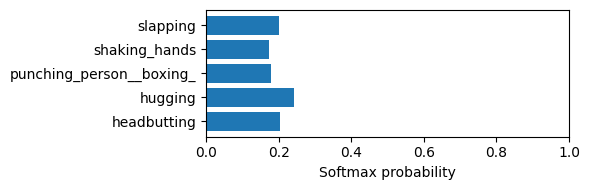

In [2]:
from notebooks.utils.workflows import inspect_model
inspection = inspect_model(prepared)
